<a href="https://colab.research.google.com/github/Aybuke211/Python_Projects/blob/main/Say%C4%B1sal_Ses_Proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Karplus-Strong Algoritması ile Gitar Sesi Sentezleme**

Örnek: E2, damping=0.99, excitation=white


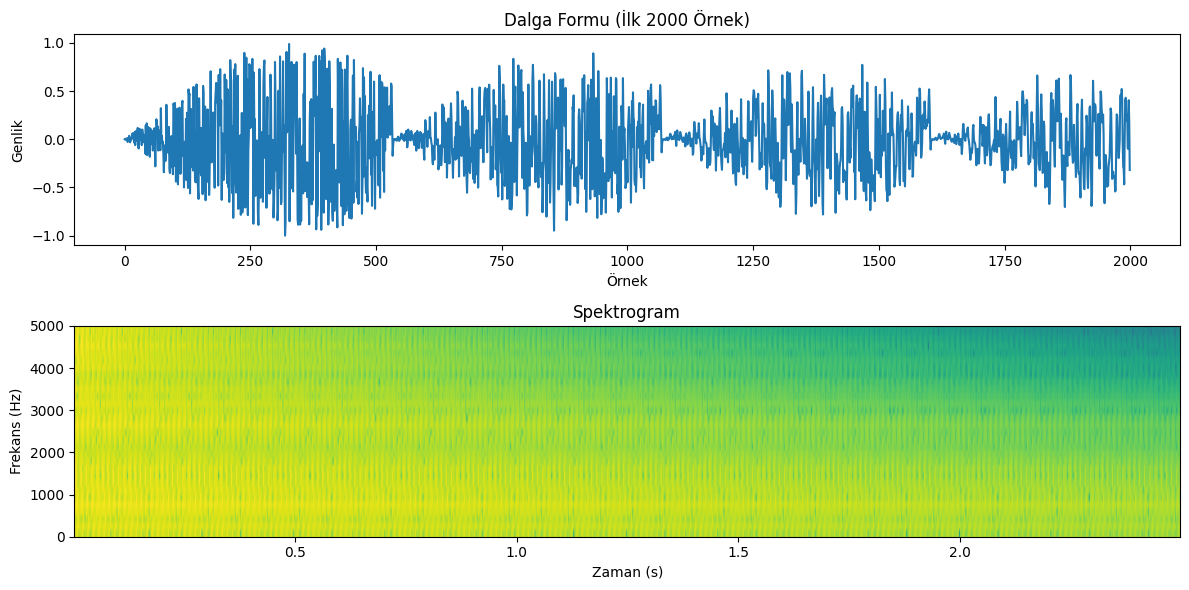

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio

# ================================
# KARPLUS-STRONG (GELİŞMİŞ)
# ================================
def karplus_strong(frequency, duration, sampling_rate=44100,
                   damping=0.996, alpha=0.5,
                   excitation_type="white", pluck_position=0.5):

    L = int(sampling_rate / frequency)

    # --- EXCITATION ---
    if excitation_type == "white":
        delay_line = np.random.uniform(-1, 1, L)

    elif excitation_type == "decay_noise":
        delay_line = np.random.uniform(-1, 1, L)
        delay_line *= np.linspace(1, 0, L)

    elif excitation_type == "impulse":
        delay_line = np.zeros(L)
        delay_line[0:int(L * 0.1)] = 1.0

    else:
        delay_line = np.random.uniform(-1, 1, L)

    # --- PLUCK POSITION EFFECT ---
    shape = np.sin(np.pi * np.linspace(0, 1, L) * pluck_position)
    delay_line *= shape

    num_samples = int(duration * sampling_rate)
    output = np.zeros(num_samples)

    output[:L] = delay_line

    # --- FEEDBACK LOOP ---
    for i in range(L, num_samples):
        new_sample = (alpha * output[i - L] +
                      (1 - alpha) * output[i - (L - 1)]) * damping
        output[i] = new_sample

    return output


# ================================
# PARAMETRELER
# ================================
Fs = 44100
duration = 2.5

# Nota frekansları (küçük gitar seti)
notes = {
    "E2": 82.41,
    "A2": 110.00,
    "D3": 146.83,
    "G3": 196.00
}

# Test parametreleri
damping_values = [0.990, 0.995, 0.999]
excitation_types = ["white", "decay_noise", "impulse"]

# ================================
# SES ÜRETİMİ
# ================================
results = []

for note_name, freq in notes.items():
    for damp in damping_values:
        for exc in excitation_types:

            sound = karplus_strong(
                frequency=freq,
                duration=duration,
                sampling_rate=Fs,
                damping=damp,
                alpha=0.7,
                excitation_type=exc,
                pluck_position=0.8
            )

            # normalize
            sound /= np.max(np.abs(sound))

            filename = f"{note_name}_{exc}_d{damp}.wav"
            wavfile.write(filename, Fs, (sound * 32767).astype(np.int16))

            results.append((sound, note_name, damp, exc))


# ================================
# ÖRNEK GÖRSELLEŞTİRME
# ================================
example_sound, note_name, damp, exc = results[0]

print(f"Örnek: {note_name}, damping={damp}, excitation={exc}")

plt.figure(figsize=(12, 6))

# Dalga formu
plt.subplot(2, 1, 1)
plt.plot(example_sound[:2000])
plt.title("Dalga Formu (İlk 2000 Örnek)")
plt.xlabel("Örnek")
plt.ylabel("Genlik")

# Spektrogram
plt.subplot(2, 1, 2)
plt.specgram(example_sound, Fs=Fs, cmap='viridis')
plt.title("Spektrogram")
plt.xlabel("Zaman (s)")
plt.ylabel("Frekans (Hz)")
plt.ylim(0, 5000)

plt.tight_layout()
plt.show()

# ================================
# SESİ DİNLE
# ================================
Audio(example_sound, rate=Fs)

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# GUI Elemanları
freq_slider = widgets.FloatSlider(value=110.0, min=80.0, max=440.0, step=1.0, description='Frekans (Hz):')
damp_slider = widgets.FloatSlider(value=0.996, min=0.950, max=0.999, step=0.001, description='Sönümleme:')
exc_dropdown = widgets.Dropdown(options=['white', 'decay_noise', 'impulse'], value='white', description='Vuruş Tipi:')
button = widgets.Button(description="Sesi Sentezle ve Çal", button_style='success')
out = widgets.Output()

def on_button_clicked(b):
    with out:
        clear_output()
        # Sentezleme fonksiyonunu çağır
        sound = karplus_strong(
            frequency=freq_slider.value,
            duration=2.0,
            damping=damp_slider.value,
            excitation_type=exc_dropdown.value
        )
        sound /= np.max(np.abs(sound))

        # Görselleştirme
        plt.figure(figsize=(10, 3))
        plt.specgram(sound, Fs=44100, cmap='magma')
        plt.title(f"Spektrogram: {freq_slider.value}Hz - {exc_dropdown.value}")
        plt.show()

        display(Audio(sound, rate=44100))

button.on_click(on_button_clicked)

# Arayüzü Göster
print("--- Karplus-Strong Canlı Test Paneli ---")
display(widgets.VBox([freq_slider, damp_slider, exc_dropdown, button]), out)

--- Karplus-Strong Canlı Test Paneli ---


Output()

Gerçek Gitar Sesi ile Kıyaslama

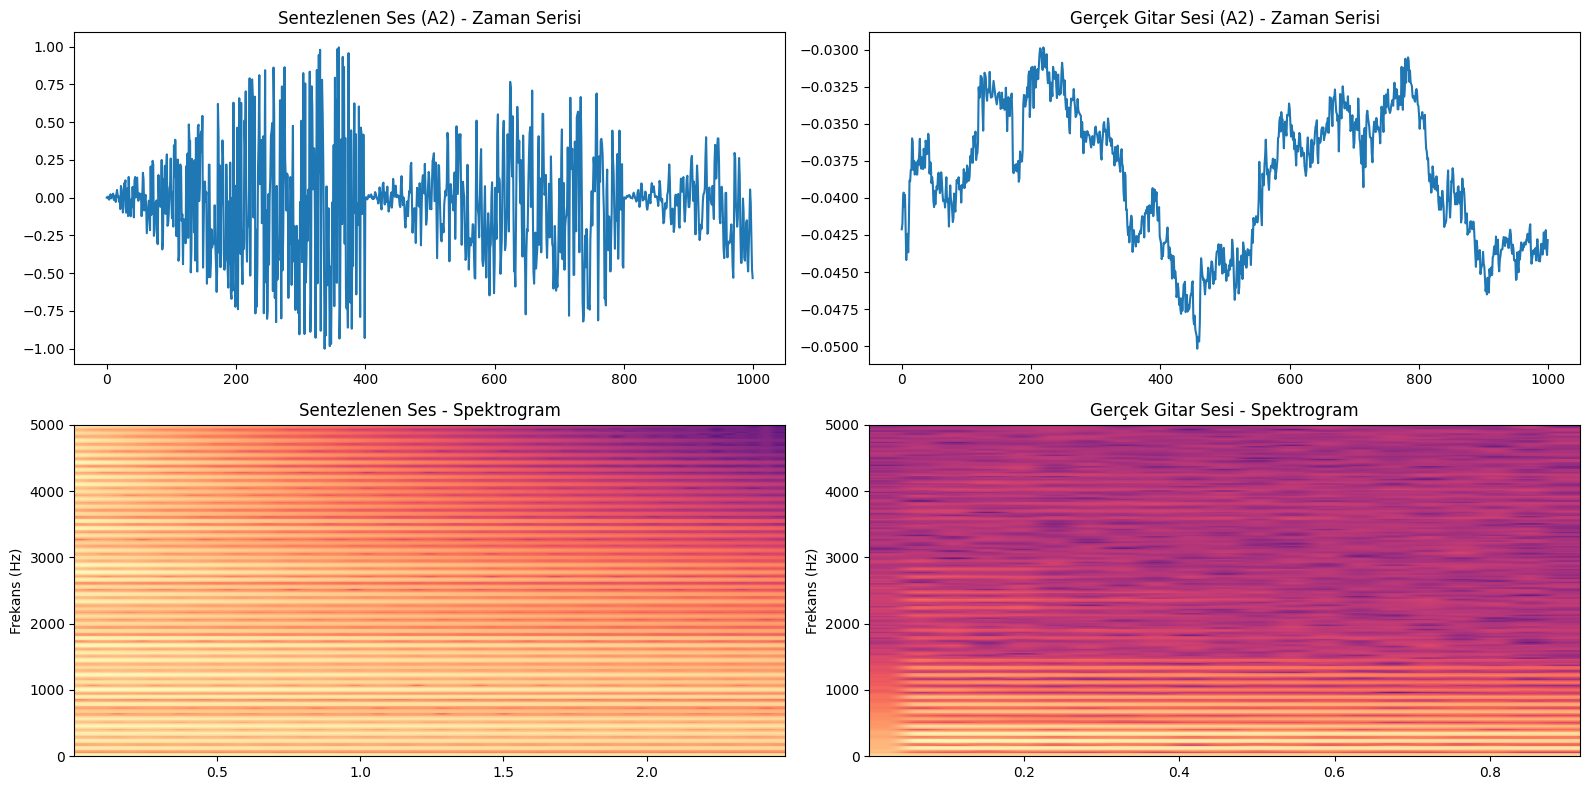

Sentezlenen Ses:


Gerçek Ses:


In [8]:
import librosa
import librosa.display

# 1. ADIM: Karşılaştırma için A2 (110 Hz) sesini sentezle
# (Hata almamak için burada açıkça tanımlıyoruz)
target_freq = 110.00 # A2 frekansı
comp_sound = karplus_strong(
    frequency=target_freq,
    duration=2.5,
    damping=0.996, # Gerçek sese yakın bir değer
    excitation_type="white"
)
comp_sound /= np.max(np.abs(comp_sound)) # Normalize et

# 2. ADIM: Gerçek sesi yükle
real_file_path = '/content/363061__nsauzede__eguitar_5a_a2.wav'
try:
    real_audio, sr = librosa.load(real_file_path, sr=44100)

    # 3. ADIM: Görselleştirme
    plt.figure(figsize=(16, 8))

    # SOL PANEL: Sentezlenen Ses
    plt.subplot(2, 2, 1)
    plt.plot(comp_sound[:1000]) # İlk 1000 örnek (Dalga formu yakın plan)
    plt.title("Sentezlenen Ses (A2) - Zaman Serisi")

    plt.subplot(2, 2, 3)
    plt.specgram(comp_sound, Fs=44100, cmap='magma', NFFT=2048)
    plt.title("Sentezlenen Ses - Spektrogram")
    plt.ylim(0, 5000) # İlgili frekans aralığı
    plt.ylabel("Frekans (Hz)")

    # SAĞ PANEL: Gerçek Gitar Sesi
    plt.subplot(2, 2, 2)
    plt.plot(real_audio[:1000])
    plt.title("Gerçek Gitar Sesi (A2) - Zaman Serisi")

    plt.subplot(2, 2, 4)
    plt.specgram(real_audio, Fs=44100, cmap='magma', NFFT=2048)
    plt.title("Gerçek Gitar Sesi - Spektrogram")
    plt.ylim(0, 5000)
    plt.ylabel("Frekans (Hz)")

    plt.tight_layout()
    plt.show()

    # SESLERİ DİNLEME (Opsiyonel)
    print("Sentezlenen Ses:")
    display(Audio(comp_sound, rate=44100))
    print("Gerçek Ses:")
    display(Audio(real_audio, rate=44100))

except FileNotFoundError:
    print(f"HATA: '{real_file_path}' bulunamadı. Dosyayı Colab'e yüklediğinizden emin olun.")